### Summary:

We don’t have as complex technical information for all studies, but do want to keep in some of these analyses with the Alberta data only. Here I'm just gonna redo and finalize associations between cell type proportions and technical covars ONLY. 

In [1]:
suppressMessages(library(dplyr))
suppressMessages(library(stringr))
suppressMessages(library(tictoc))

suppressMessages(library(ggplot2))
suppressMessages(library(ggpubr))
suppressMessages(library(RColorBrewer))

# Set up

In [2]:
overall_outdir <- '/nfs/lab/projects/multiomic_islet/outputs/revisions_outputs/trait_associations'
indir <- file.path(overall_outdir,'celltype_props','inputs')
outdir <- file.path(overall_outdir,'celltype_props','outputs')

In [3]:
celltypes <- c('beta', 'alpha', 'delta', 'gamma', 'acinar',
               'ductal', 'endothelial', 'immune', 'stellate')

celltype_colors = c('acinar'='#09850B', 'alpha'='#F51646', 'beta'='#3F98E0',
                    'delta'='#FFA946', 'ductal'='#F5DE6C', 'endothelial'='#752BBA', 
                    'gamma'='#A1D99B', 'immune'='#F598C9', 'stellate'='#AB7345')

In [4]:
trait_colors <- c('age'='#BA4E72','BMI'='#88BA4E','HbA1c'='#8D4EBA','culture_time'='#DD6503',
                  'cold_ischemia_time'='#52B3D3','pancreas_weight'='#FCD121','purity'="#4F6FBA",
                  'TSSe'='#52B3D3')
trait_colors2 <- c('Female'="#C9B64A",'Male'='#E3DBB8',
                   'Liberase MTF C/T GMP grade'='#4B51C9','Collagenase Gold 800'='#262A7E',
                   'Fibrotic'='#8D432A','Inconsistent'='#BC5938','Normal'='#D2846A','Soft'='#E7BEB1',
                   'Alberta'='pink','City of Hope National Medical Center'='purple', 'nPOD'='dark blue',
                   'Tulane'='green4', 'University of Pennsylvania'='orange2', 'UPenn'='orange2', 
                   'University of Wisconsin'='yellow','10Xv2'='light blue', '10Xv3'='light pink', 'Multiome'='light yellow')
options(repr.plot.width=5, repr.plot.height=5)
theme_set(theme_classic())

In [5]:
meta_fp <- file.path(overall_outdir, 'all_datasets_donor_metadata3.tsv')

# Read in metadata and check for outliers

In [6]:
# Read in expanded metadata table
meta <- read.table(meta_fp, sep='\t', header=1) %>%
            subset(dataset %in% c('Alberta','HPAP','Wang')) %>%
            subset(dataset!='Wang' | assays!='Multiome')
head(meta)
dim(meta)
meta$sample

,sample,age,sex,BMI,HbA1c,dataset,culture_time,TSSe,tissue_source,chemistry,assays,race_ancestry_ethnicity,purity,cause_of_death
,<chr>,<int>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
1,R207,50,Female,22.2,NA,Alberta,70,3.450389,Alberta,Multiome,Multiome,NA,90,NA
2,R217,71,Female,35.5,6.3,Alberta,15,3.530508,Alberta,Multiome,Multiome,NA,80,NA
3,R218,73,Female,28.4,5.9,Alberta,70,3.641667,Alberta,Multiome,Multiome,NA,80,NA
4,R221,44,Male,30.5,5.3,Alberta,136,3.792649,Alberta,Multiome,Multiome,NA,75,NA
5,R223,54,Male,27.0,5.8,Alberta,64,2.992320,Alberta,Multiome,Multiome,NA,90,NA
6,R226,30,Female,32.3,4.9,Alberta,16,3.864731,Alberta,Multiome,Multiome,NA,95,NA


[1] 73 14

[1] "R207"     "R217"     "R218"     "R221"     "R223"     "R226"    
 [7] "R228"     "R234"     "R237"     "R238"     "R246"     "R247"    
[13] "R275"     "R284"     "R290"     "R292"     "R316"     "R317"    
[19] "R319"     "R325"     "R326"     "R327"     "R332"     "R353"    
[25] "R354"     "R362"     "R363"     "R364"     "HPAP-022" "HPAP-026"
[31] "HPAP-034" "HPAP-035" "HPAP-036" "HPAP-037" "HPAP-039" "HPAP-040"
[37] "HPAP-042" "HPAP-044" "HPAP-045" "HPAP-047" "HPAP-049" "HPAP-050"
[43] "HPAP-052" "HPAP-053" "HPAP-054" "HPAP-056" "HPAP-059" "HPAP-063"
[49] "HPAP-067" "HPAP-069" "HPAP-072" "HPAP-074" "HPAP-075" "HPAP-077"
[55] "HPAP-080" "HPAP-082" "HPAP-092" "HPAP-099" "HPAP-101" "HPAP-103"
[61] "HPAP-104" "HPAP-105" "JYH792"   "MM110"    "MM123"    "MM124"   
[67] "MM56"     "MM59"     "MM80"     "MM86"     "MM89"     "MM95"    
[73] "MM98"

In [7]:
#make a few minor modifications
meta[meta$tissue_source=='University of Pennsylvania','tissue_source'] <- 'UPenn'
meta[meta$race_ancestry_ethnicity=='African American' & !is.na(meta$race_ancestry_ethnicity),'race_ancestry_ethnicity'] <- 'black'
meta[meta$race_ancestry_ethnicity=='Caucasian' & !is.na(meta$race_ancestry_ethnicity),'race_ancestry_ethnicity'] <- 'white'
meta[meta$race_ancestry_ethnicity=='White/Caucasian' & !is.na(meta$race_ancestry_ethnicity),'race_ancestry_ethnicity'] <- 'white'
meta[meta$race_ancestry_ethnicity=='Hispanic/Latino' & !is.na(meta$race_ancestry_ethnicity),'race_ancestry_ethnicity'] <- 'hispanic'
meta[meta$race_ancestry_ethnicity=='Hispanic' & !is.na(meta$race_ancestry_ethnicity),'race_ancestry_ethnicity'] <- 'hispanic'

In [8]:
#scale all the continuous data
for (col in colnames(meta)[c(2,4,5,7,8)]){
    new_name <- paste0(col,'_scaled')
    meta[[new_name]] <- as.numeric(scale(meta[,col]))
}

In [21]:
cont_covars <- c('age_scaled', 'BMI_scaled', 'HbA1c_scaled')
disc_covars <- c('sex','cause_of_death')

# add_covars1 <- c('sex','chemistry', 'dataset', 'purity','cause_of_death')
add_covars2 <- c('sex','dataset', 'purity')

### Quick test for outliers in meta data

In [10]:
# Extract data from one column in metadata
for (colname in cont_covars){
    data <- meta[,colname]
    names(data) <- meta$sample
    data <- data[!is.na(data)]
    
    # Convert to z-scores
    zscores <- (data - mean(data))/sd(data)
    
    # Gather outlier samples
    sd_cutoff=3
    outliers <- names(zscores[abs(zscores) >= sd_cutoff])
    print(c(colname,outliers))
}

[1] "age_scaled"
[1] "BMI_scaled"
[1] "HbA1c_scaled"


In [11]:
#also check on distribution of disc covars
for(colname in disc_covars){
    print(colname)
    print(table(meta[,colname]))
}

[1] "sex"

Female   Male 
    26     47 
[1] "cause_of_death"

        Anoxia Cardiac arrest    Head trauma         Stroke 
            20              1             11             13 


In [12]:
#no outliers to remove!
meta_fin <- meta

for(cov in disc_covars){
    meta_fin[,cov] <- factor(meta_fin[,cov])
}

In [13]:
#print out how many donors are removed by including HbA1c
table(is.na(meta_fin$HbA1c))


FALSE  TRUE 
   66     7 

# Overall proportion tests

## Functions to run proportion tests

In [14]:
### Function to run a glm model for a ct_prop vs one var, including other vars as covars
run_ct_prop_glm <- function(meta, ct_prop, var, other_vars){
    #then fit glm and return info
    my_design <- as.formula(paste0(sprintf('%s ~ %s',ct_prop, var),paste0(rep(' + ',length(other_vars)), other_vars,collapse='')))
    print(my_design)
    fit <- glm(my_design, data=meta)
    return(fit)
}


### Wrapper function which will apply the glm model to all combinations of meta traits and cell prop traits
glm_wrapper <- function(meta, trait_list, ct_prop_list, add_vars, test_str, outdir){
    # Create results df with filler columns (to set the row length)
    results <- data.frame(filler1=rep(0, length(trait_list)), filler2=rep(1, length(trait_list)))
    
    # For each cell type, make glms by each trait in trait_list, using remaining traits as covars
    for (ct_prop in ct_prop_list){
        ct <- unlist(str_split(ct_prop, '_'))[1]
        test_results <- run_ct_prop_glm(meta, ct_prop, trait_list[1], c(trait_list[-1],add_vars))
        test_results_df <- coef(summary(test_results))
        test_results_cut <- test_results_df[seq(2,1+length(trait_list)),c(1,3,4)]
        results <- cbind(results, test_results_cut)
        
    }
    # Finalize results formatting
    results <- results[trait_list,-c(1,2)] #remove filler columns
    row.names(results) <- trait_list
    ct_list <- str_split_fixed(ct_prop_list,'_',2)[,1]
    colnames(results) <- c(t(outer(ct_list, c('coef', 'tvalue', 'pvalue'), FUN = "paste", sep='_')))
    
    # Write results to a file and also return it for printouts
    fp <- file.path(outdir, sprintf('%s_cont.multivar_glm.txt',test_str))
    write.table(results, fp, sep='\t', quote=FALSE)
    return(results)
}

In [15]:
### Function to run an Anova test to compare two columns of metadata
### Col1 is the categorical variable of interest and col2 is the ct prop
compare_features_anova <- function(meta, col1, col2){
    # cut down meta to features of interest
    data <- meta[,c(col1,col2)]
    colnames(data) <- c('var','prop')
    
    #run anova and return summary
    return(summary(aov(prop ~ var, data)))
}


### Wrapper function for comparing sex with cell type prop features
anova_wrapper <- function(meta, trait_list, ct_prop_list, test_str, outdir){
    # For each cell type, run anovas for each trait in trait_list
    results <- list()
    for (ct_prop in ct_prop_list){
        ct <- unlist(str_split(ct_prop, '_'))[1]
        ct_results <- list()
        for(trait in trait_list){
            ct_results[[trait]] <- compare_features_anova(meta, trait, ct_prop)
        } 
        #combine anova results in readable format
        temp <- unlist(ct_results)
        ct_results_fin <- data.frame(stat = temp[grepl('F value1',names(temp))], pvalue = temp[grepl('Pr\\(>F\\)1',names(temp))])
        row.names(ct_results_fin) <- trait_list
        results[[ct]] <- ct_results_fin
    }
    # Finalize results and write to a file 
    results_fin <- do.call(cbind, results)
    colnames(results_fin) <- gsub('\\.pvalue','_pvalue',colnames(results_fin))
    colnames(results_fin) <- gsub('\\.stat','_stat',colnames(results_fin))
    fp <- file.path(outdir, sprintf('%s_disc.anova_onesided.txt',test_str))
    write.table(results_fin, fp, sep='\t', quote=FALSE)
    return(results_fin)
}

In [16]:
#adjust pvalues function
adjust_prop_assoc_pvals <- function(res_fp, ct_level, ct_list){
    # Read in GLM results 
    res_df <- read.table(res_fp, sep='\t')
    
    qvalues <- list()
    for(celltype in ct_list){
        colname <- paste0(celltype,'_pvalue')
        pvals <- res_df[,colname]
        qvals <- p.adjust(pvals, method='BH')
        qvalues[[celltype]] <- qvals
    }
    
    qvalues_df <- as.data.frame(qvalues)
    row.names(qvalues_df) <- row.names(res_df)
    colnames(qvalues_df) <- paste0(colnames(qvalues_df),'_qvalue')
    
    #reorganize for output
    res <- cbind(res_df, qvalues_df)
    test <- res %>% tibble::rownames_to_column(var='trait') %>%
                    tidyr::pivot_longer(!trait)
    test <- cbind(test, str_split_fixed(test$name,pattern='_',n=2)) %>%
                rename(celltype='1',test='2') %>% select(-name)
    test <- test %>% tidyr::pivot_wider(names_from=test, values_from=value)
    
    #write to file
    out_fp <- gsub('\\.txt','_wBH_FDR.txt',res_fp)
    write.table(test,out_fp,sep='\t',row.names=FALSE, quote=FALSE)
    print(subset(test,qvalue<0.1))
}

In [17]:
prop_test_wrapper <- function(fin_df, meta_fin, ct_props, covars, add_vars, test_str, outdir, covar_type='cont'){
    #add proportion df to meta so can just pass one df to functions
    meta_use <- left_join(fin_df, meta_fin, by='sample')

    #now run association tests
    if(covar_type=='cont'){
        res <- glm_wrapper(meta_use, covars, ct_props, add_vars, test_str, outdir)
        res_fp <- file.path(outdir, sprintf('%s_%s.multivar_glm.txt', test_str, covar_type))
    } else if(covar_type=='disc'){
        res <- anova_wrapper(meta_use, covars, ct_props, test_str, outdir)
        res_fp <- file.path(outdir, sprintf('%s_%s.anova_onesided.txt', test_str, covar_type))
    }

    #finally adjust pvalues
    adjust_prop_assoc_pvals(res_fp, ct_level, celltypes)
}

## RNA proportions

In [22]:
#read in either 10k scaled counts or sqrt compartment proportion 
prop_fp <- file.path(indir, 'all_datasets_donor_celltype_RNA_props.tsv')
df <- read.table(prop_fp, sep='\t', header=1)

# prep list of cell type prop values to test -- adjust based on input data
ct_props <- paste(celltypes, 'cells_rna_prop_sqrt', sep='_')

In [23]:
prop_test_wrapper(df, meta_fin, ct_props, cont_covars, add_covars2, 'RNA', outdir, covar_type='cont')

beta_cells_rna_prop_sqrt ~ age_scaled + BMI_scaled + HbA1c_scaled + 
    sex + dataset + purity
<environment: 0x558230db40f8>
alpha_cells_rna_prop_sqrt ~ age_scaled + BMI_scaled + HbA1c_scaled + 
    sex + dataset + purity
<environment: 0x5582314e2dc8>
delta_cells_rna_prop_sqrt ~ age_scaled + BMI_scaled + HbA1c_scaled + 
    sex + dataset + purity
<environment: 0x558231630b08>
gamma_cells_rna_prop_sqrt ~ age_scaled + BMI_scaled + HbA1c_scaled + 
    sex + dataset + purity
<environment: 0x558231718ca0>
acinar_cells_rna_prop_sqrt ~ age_scaled + BMI_scaled + HbA1c_scaled + 
    sex + dataset + purity
<environment: 0x558231801fe8>
ductal_cells_rna_prop_sqrt ~ age_scaled + BMI_scaled + HbA1c_scaled + 
    sex + dataset + purity
<environment: 0x5582318e1850>
endothelial_cells_rna_prop_sqrt ~ age_scaled + BMI_scaled + HbA1c_scaled + 
    sex + dataset + purity
<environment: 0x558231a19858>
immune_cells_rna_prop_sqrt ~ age_scaled + BMI_scaled + HbA1c_scaled + 
    sex + dataset + purity
<envir

In [24]:
prop_test_wrapper(df, meta_fin, ct_props, disc_covars, c(), 'RNA', outdir, covar_type='disc')

# A tibble: 1 × 5
  trait          celltype  stat pvalue qvalue
  <chr>          <chr>    <dbl>  <dbl>  <dbl>
1 cause_of_death immune    4.86 0.0169 0.0339


In [25]:
#printout all sig results
res_fp1 <- file.path(outdir, 'RNA_cont.multivar_glm_wBH_FDR.txt')
res1 <- read.table(res_fp1, sep='\t', header=1)
subset(res1, qvalue < 0.1)

res_fp2 <- file.path(outdir, 'RNA_disc.anova_onesided_wBH_FDR.txt')
res2 <- read.table(res_fp2, sep='\t', header=1)
subset(res2, qvalue < 0.1)

,trait,celltype,coef,tvalue,pvalue,qvalue
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
6,age_scaled,ductal,-0.03949299,-2.369705,0.022590696,0.067772089
11,BMI_scaled,alpha,0.06499256,3.127097,0.003242479,0.009727436
14,BMI_scaled,acinar,-0.05543737,-2.269504,0.028564392,0.085693176
15,BMI_scaled,ductal,-0.02578239,-1.934680,0.059949787,0.089924680


,trait,celltype,stat,pvalue,qvalue
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
17,cause_of_death,immune,4.857217,0.01693341,0.03386681


## ATAC proportions

In [26]:
#read in either 10k scaled counts or sqrt compartment proportion 
prop_fp <- file.path(indir, 'all_datasets_donor_celltype_ATAC_props.tsv')
df <- read.table(prop_fp, sep='\t', header=1)

# prep list of cell type prop values to test -- adjust based on input data
ct_props <- paste(celltypes, 'cells_atac_prop_sqrt', sep='_')

In [27]:
prop_test_wrapper(df, meta_fin, ct_props, cont_covars, add_covars2, 'ATAC', outdir, covar_type='cont')

beta_cells_atac_prop_sqrt ~ age_scaled + BMI_scaled + HbA1c_scaled + 
    sex + dataset + purity
<environment: 0x558230305d48>
alpha_cells_atac_prop_sqrt ~ age_scaled + BMI_scaled + HbA1c_scaled + 
    sex + dataset + purity
<environment: 0x55822f664ac0>
delta_cells_atac_prop_sqrt ~ age_scaled + BMI_scaled + HbA1c_scaled + 
    sex + dataset + purity
<environment: 0x55822f415250>
gamma_cells_atac_prop_sqrt ~ age_scaled + BMI_scaled + HbA1c_scaled + 
    sex + dataset + purity
<environment: 0x55822dc9ca30>
acinar_cells_atac_prop_sqrt ~ age_scaled + BMI_scaled + HbA1c_scaled + 
    sex + dataset + purity
<environment: 0x558230949388>
ductal_cells_atac_prop_sqrt ~ age_scaled + BMI_scaled + HbA1c_scaled + 
    sex + dataset + purity
<environment: 0x558230cf4b80>
endothelial_cells_atac_prop_sqrt ~ age_scaled + BMI_scaled + 
    HbA1c_scaled + sex + dataset + purity
<environment: 0x5582310095e8>
immune_cells_atac_prop_sqrt ~ age_scaled + BMI_scaled + HbA1c_scaled + 
    sex + dataset + purit

In [28]:
prop_test_wrapper(df, meta_fin, ct_props, disc_covars, c(), 'ATAC', outdir, covar_type='disc')

# A tibble: 1 × 5
  trait celltype  stat pvalue qvalue
  <chr> <chr>    <dbl>  <dbl>  <dbl>
1 sex   beta      4.29 0.0423 0.0846


In [29]:
#printout all sig results
res_fp1 <- file.path(outdir, 'ATAC_cont.multivar_glm_wBH_FDR.txt')
res1 <- read.table(res_fp1, sep='\t', header=1)
subset(res1, qvalue < 0.1)

res_fp2 <- file.path(outdir, 'ATAC_disc.anova_onesided_wBH_FDR.txt')
res2 <- read.table(res_fp2, sep='\t', header=1)
subset(res2, qvalue < 0.1)

,trait,celltype,coef,tvalue,pvalue,qvalue
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
6,age_scaled,ductal,-0.043981248,-2.350843,0.0228865,0.06865949
17,BMI_scaled,immune,-0.009277144,-2.400157,0.0203151,0.06094530


,trait,celltype,stat,pvalue,qvalue
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,sex,beta,4.293205,0.0422995,0.084599


# Plot summaries of results

### glm results

In [32]:
### Function for reading in a glm output table and making a summary plot
plot_glm_summary <- function(fp, title, major_colors, sig_cutoff=0.1){
    #read in file and format for plotting
    res <- read.table(fp, sep='\t', header=TRUE)
    data <- res
    
    # Add in additional information needed for plotting
    data$color <- major_colors[data$celltype]
    data$sig_pos <- ifelse(data$qvalue <= sig_cutoff & data$coef > 0, '*', '')
    data$sig_neg <- ifelse(data$qvalue <= sig_cutoff & data$coef < 0, '*', '')

    # Make grouped barplot of desired metadata
    options(repr.plot.width=24, repr.plot.height=8)
    theme_set(theme_classic())
    p1 <- ggplot(data, aes(fill=celltype, y=coef, x=trait)) + 
            geom_bar(position="dodge", width = 0.6, stat="identity") + 
            geom_text(aes(trait, coef, label=sig_pos), position=position_dodge(width=0.6), size=10, vjust=-0.05, color='black') +
            geom_text(aes(trait, coef, label=sig_neg), position=position_dodge(width=0.6), size=10, vjust=1.5, color='black') +
            labs(x = "Trait", y = "GLM Coef", color="Cell Type", title=title) + 
            scale_fill_manual(values=major_colors) +  
            theme(axis.text.x=element_text(size=20, vjust=0.5, angle=45),
                    axis.text.y=element_text(size=20, vjust=0.5),
                    axis.title.x = element_text(size=25, vjust=-0.35),
                    axis.title.y = element_text(size=25, vjust=0.5),
                    plot.title = element_text(size=25, hjust=0.5, face="bold"),
                    legend.position='none')
    print(p1)
}

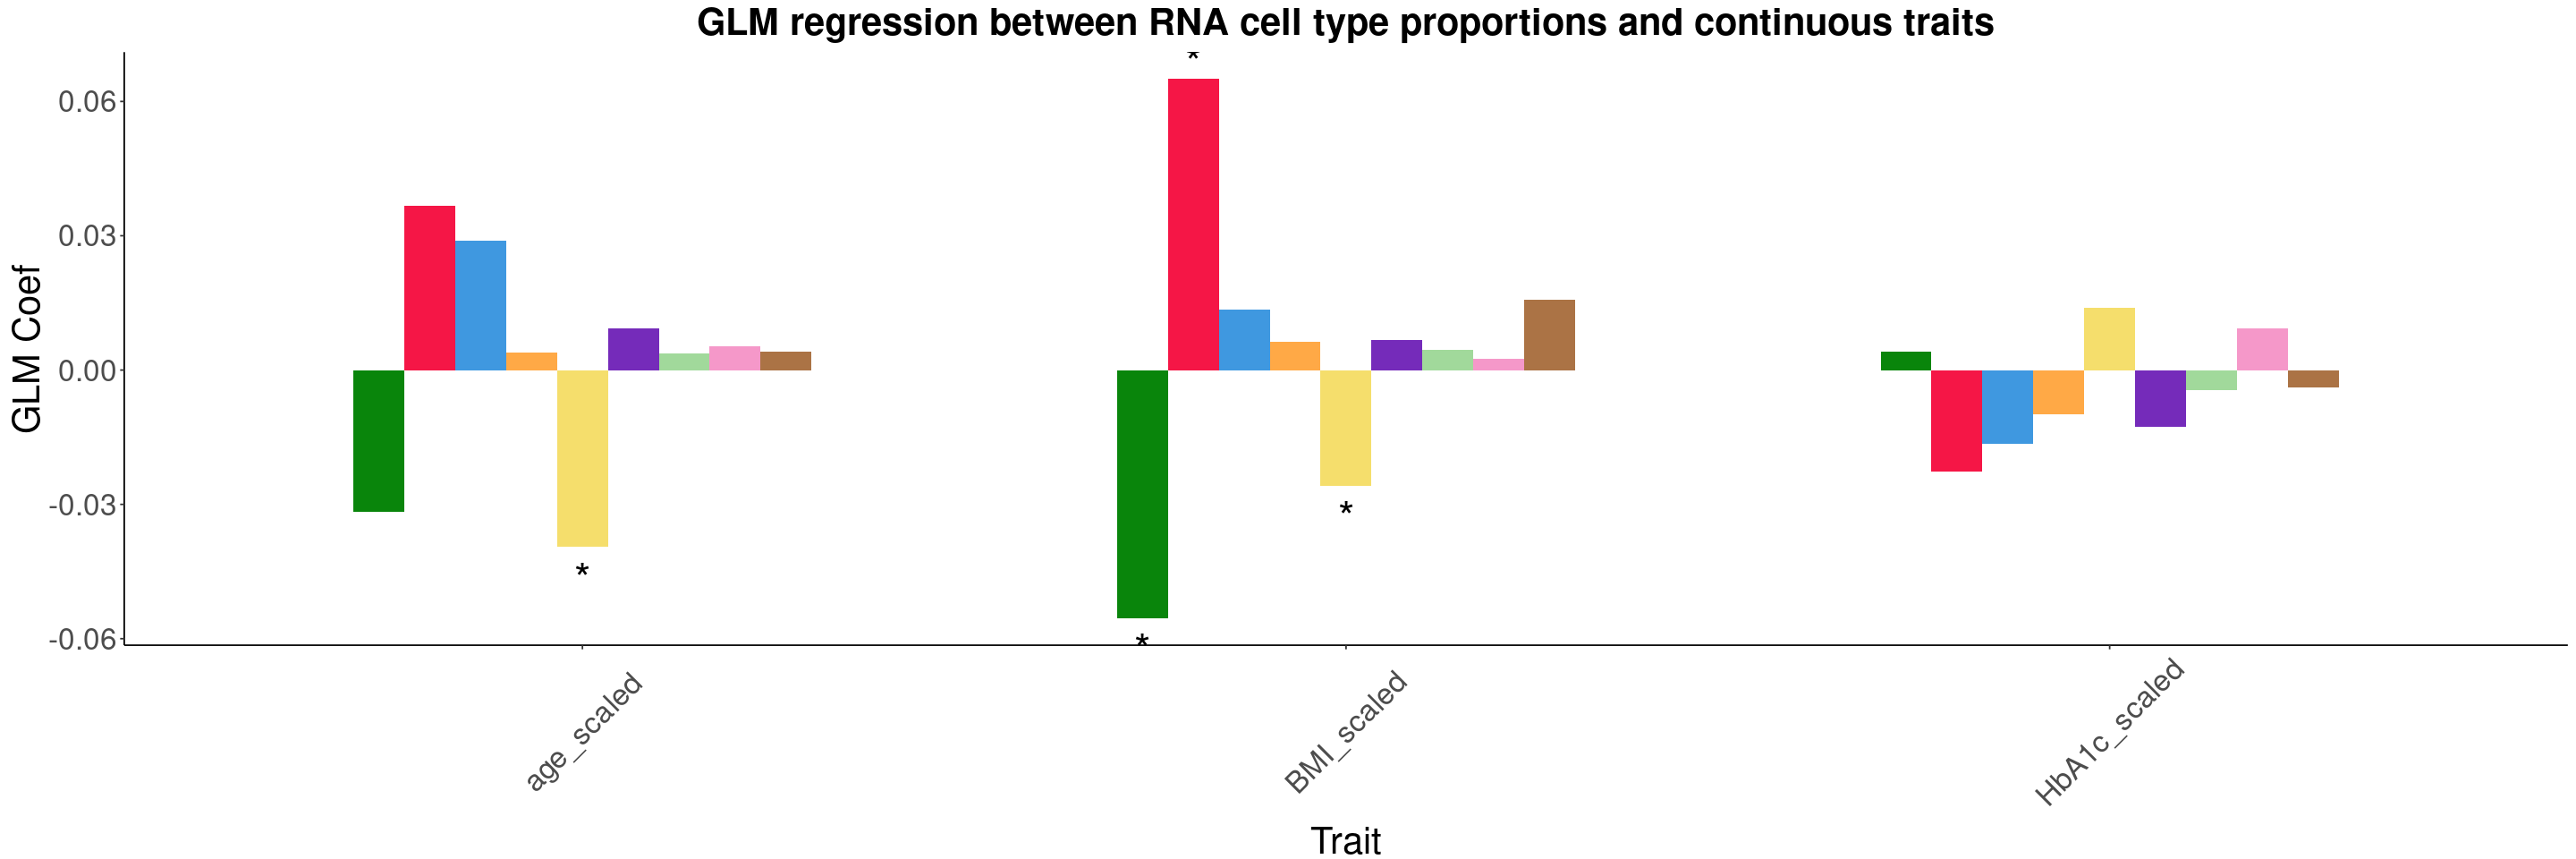

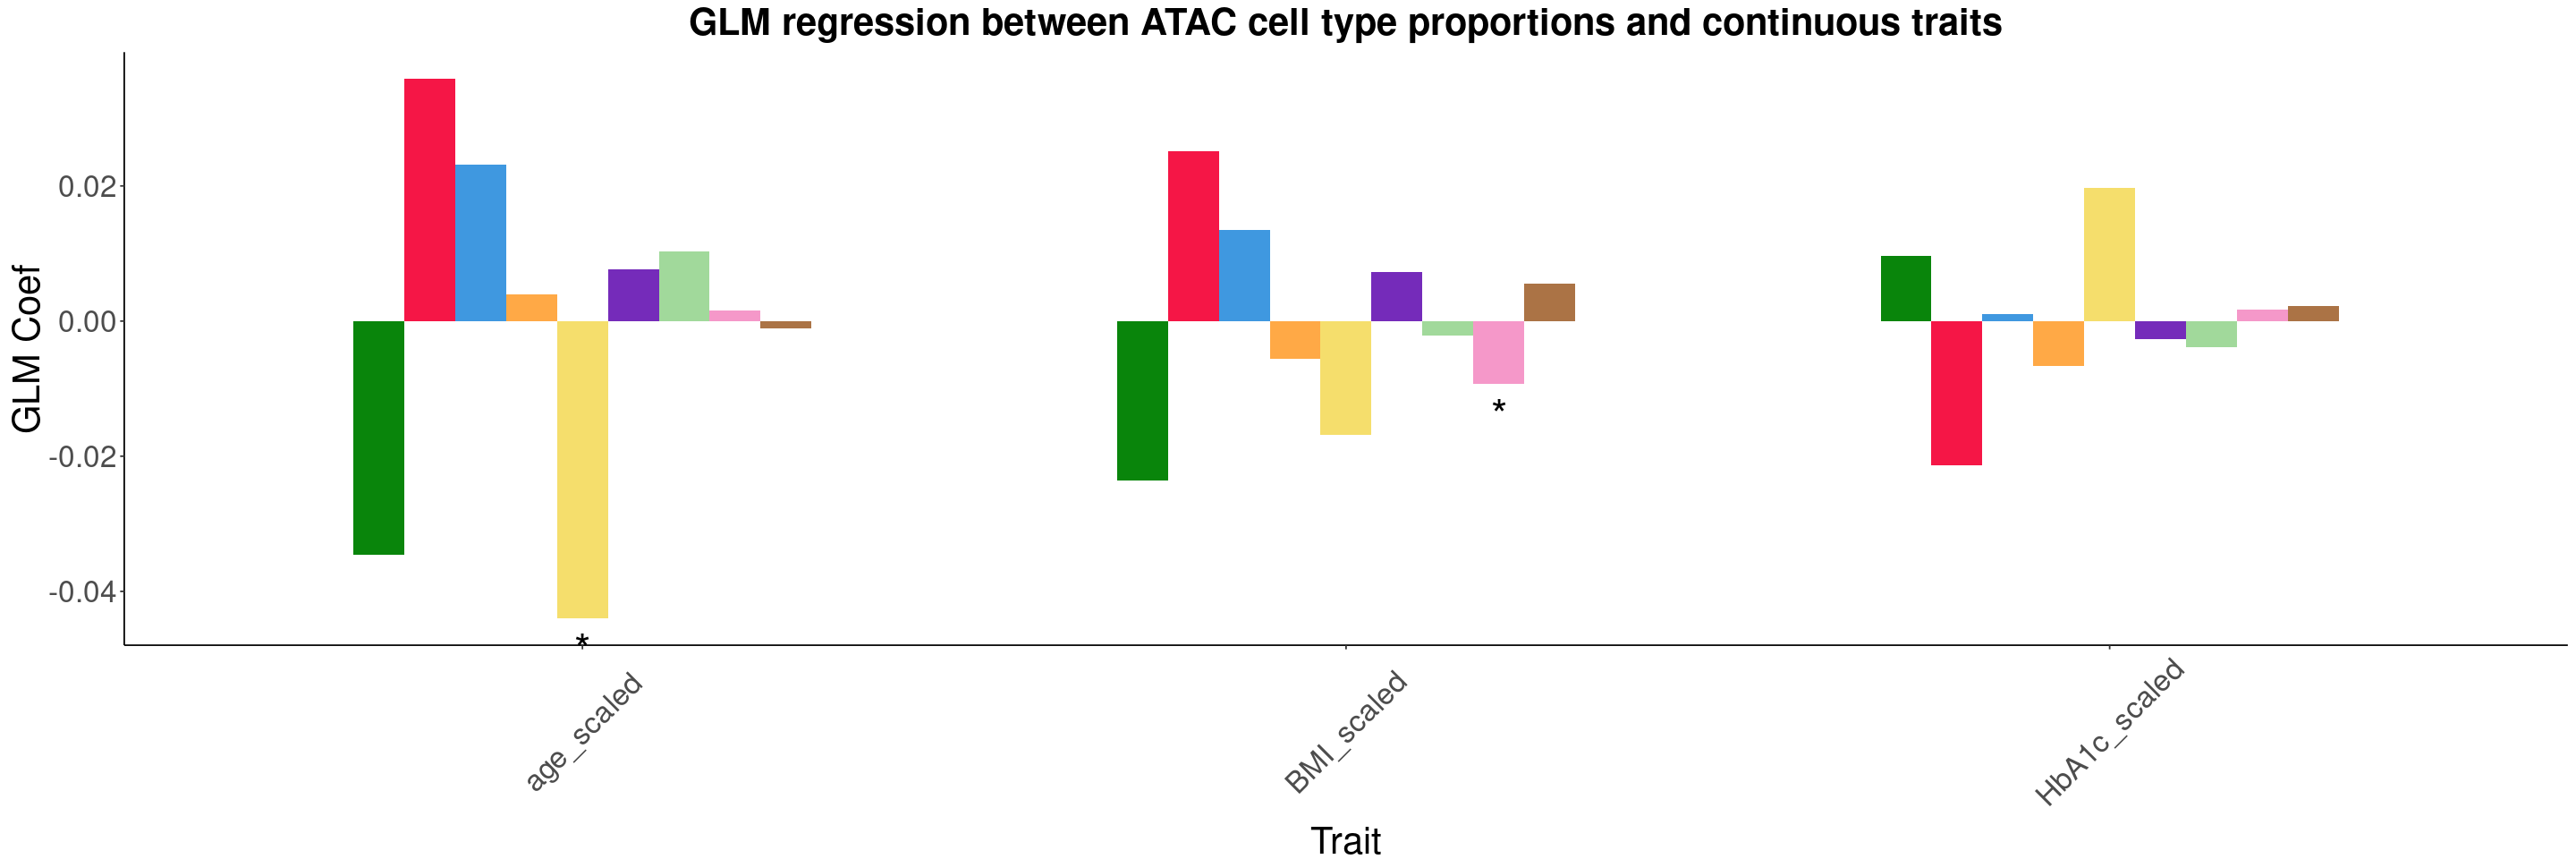

In [33]:
fp <- file.path(outdir, 'RNA_cont.multivar_glm_wBH_FDR.txt') 
title <- 'GLM regression between RNA cell type proportions and continuous traits'
plot_glm_summary(fp, title, celltype_colors)

fp <- file.path(outdir, 'ATAC_cont.multivar_glm_wBH_FDR.txt') 
title <- 'GLM regression between ATAC cell type proportions and continuous traits'
plot_glm_summary(fp, title, celltype_colors)

### anova results
high F-value means means of groups are more different (same with t-value)

In [34]:
### Function for reading in a glm output table and making a summary plot
plot_anova_summary <- function(fp, title, major_colors, sig_cutoff=0.05){
    #read in file and format for plotting
    res2 <- read.table(fp, sep='\t', header=1)
    data <- res2
    
    # Add in additional information needed for plotting
    data$color <- major_colors[data$celltype]
    data$sig <- ifelse(data$pvalue <= sig_cutoff, '*', '')

    # Make grouped barplot of desired metadata
    options(repr.plot.width=12, repr.plot.height=6)
    theme_set(theme_classic())
    p1 <- ggplot(data, aes(fill=celltype, y=stat, x=trait)) + 
            geom_bar(position="dodge", width = 0.6, stat="identity") + 
            geom_text(aes(trait, stat, label=sig), position=position_dodge(width=0.6), size=10, vjust=-0.05) +
            labs(x = "Trait", y = "Stat (T-value or F-value)", color="Cell Type", title=title) + 
            scale_fill_manual(values=major_colors) +  
            theme(axis.text.x=element_text(size=18, vjust=0.5, angle=15),
                    axis.text.y=element_text(size=18, vjust=0.5),
                    axis.title.x = element_text(size=20, vjust=-0.35),
                    axis.title.y = element_text(size=20, vjust=0.5),
                    plot.title = element_text(size=20, hjust=0.5, face="bold"),
                    legend.position='none')
    print(p1)
}

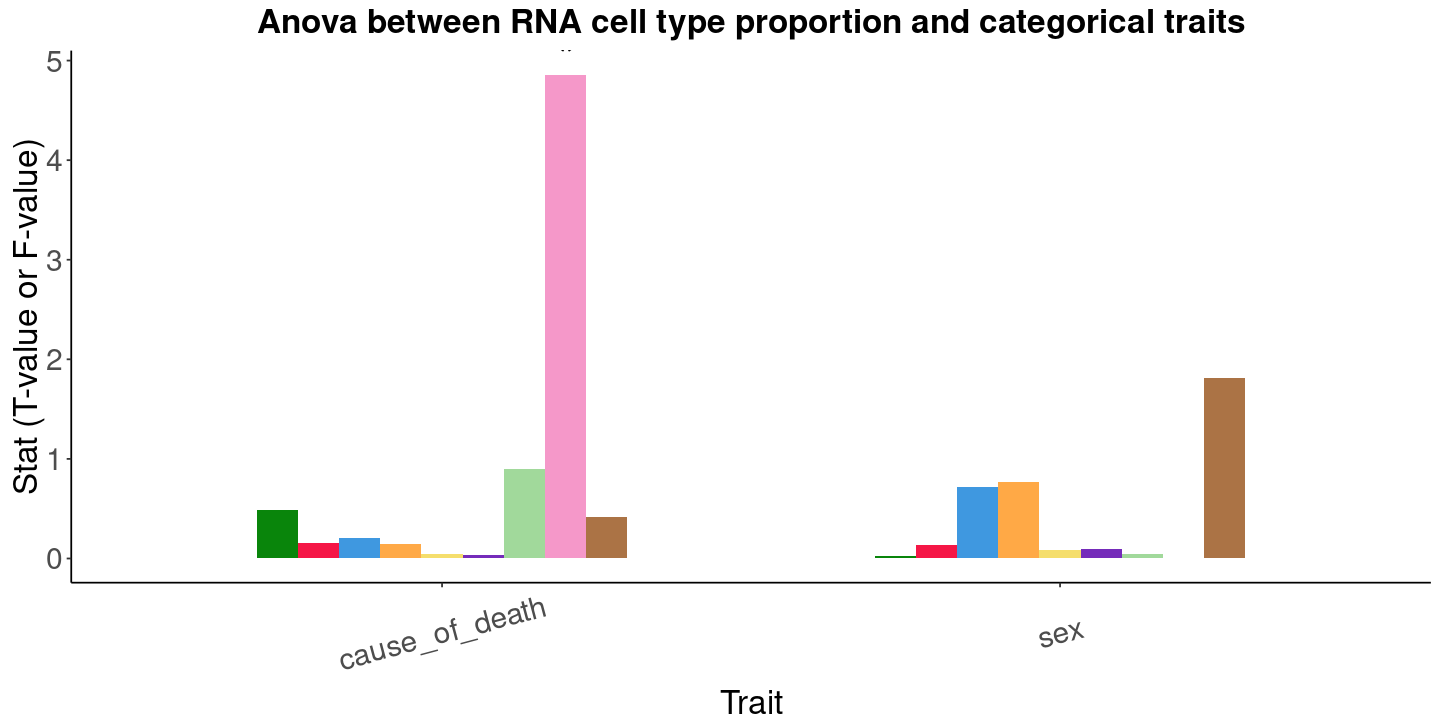

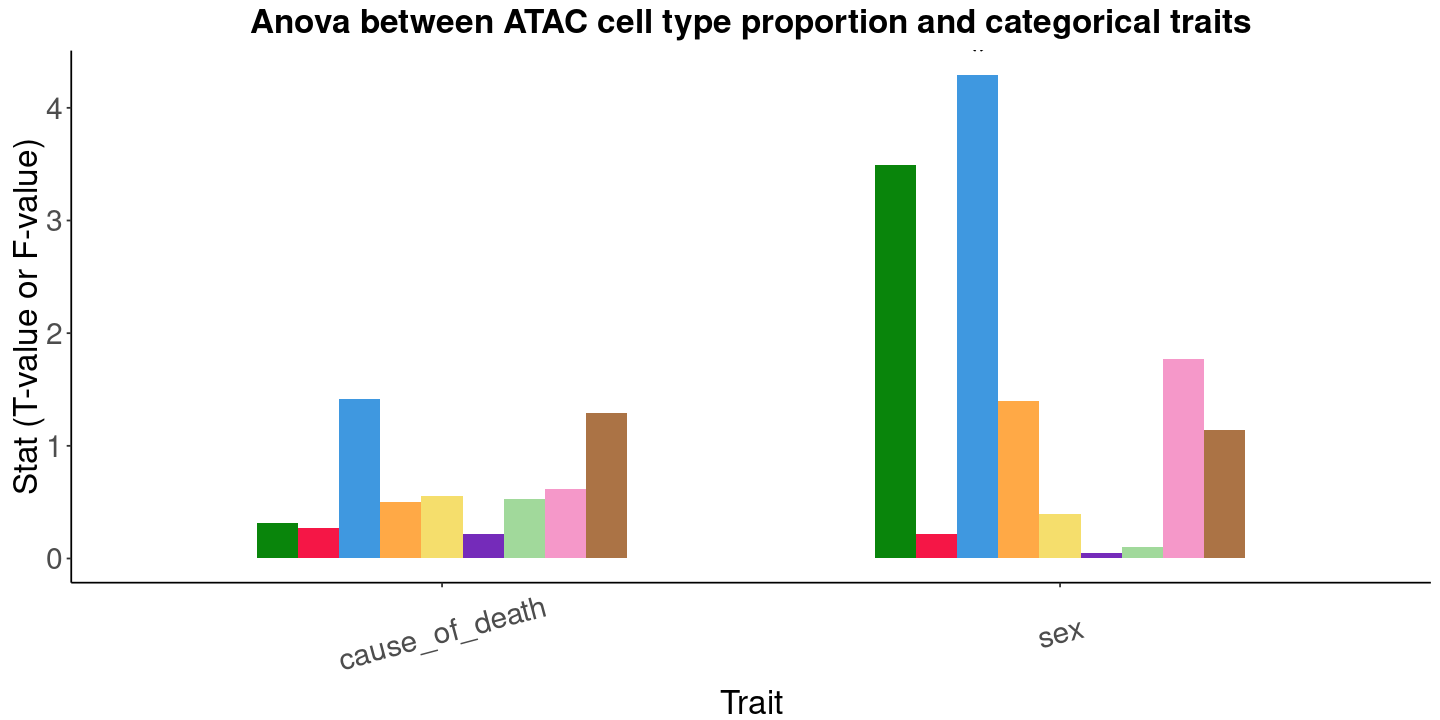

In [35]:
fp <- file.path(outdir, 'RNA_disc.anova_onesided_wBH_FDR.txt')
title <- 'Anova between RNA cell type proportion and categorical traits'
plot_anova_summary(fp, title, celltype_colors)

fp <- file.path(outdir, 'ATAC_disc.anova_onesided_wBH_FDR.txt')
title <- 'Anova between ATAC cell type proportion and categorical traits'
plot_anova_summary(fp, title, celltype_colors)

# Make plots for significant relationships of interest

In [36]:
### Function to compare the correlation of two columns in meta
### Also plots the relationship bt the two variables + a fit line?

compare_two_features <- function(meta, col1, col2, res_str, color, cont=TRUE){
    # Cut down dataframe for corr and ggplot 
    df <- meta[,c(col1, col2,'dataset')]
    df <- df[!is.na(df[,col2]),]
    colnames(df) <- c('val1', 'val2','dataset')

    # make color palette
    colors <- colorRampPalette(c('black',color,"white"))(8)[seq(3,6)]
    names(colors) <- c('Alberta','HPAP','Qadir','Wang')
    
    ### If is continuous variable make a scatter plot, otherwise make violin plot
    if(cont==TRUE){
        # Make basic plot to visualize relationship
        options(repr.plot.width=6, repr.plot.height=6)
        theme_set(
            theme_bw())
        p1 <- ggplot(data=df, aes(x=val1, y=val2, color=dataset)) + 
                geom_point(size=6) + #scale_color_manual(values=colors) +
                labs(x = col1, y = col2, title=res_str) + 
                theme(axis.title=element_text(size=20),
                      axis.text.y=element_text(size=15),
                      axis.text.x=element_text(size=15, angle=30, vjust=0.5),
                      legend.title=element_text(size=15),
                      legend.text=element_text(size=15),
                      panel.grid.major=element_line(color='grey', size=0.5, linetype=2),
                      panel.grid.minor=element_blank(),
                      panel.border=element_rect(color='black',fill=NA, size=1))
    } else {
        # Make violinplot comparing cell type propotion across discrete covar
        options(repr.plot.width=6, repr.plot.height=6)
        theme_set(
            theme_classic())

        p1 <- ggplot(data=df, aes(x=val2, y=val1, fill=dataset)) + 
                geom_violin(trim=FALSE) + 
                scale_fill_manual(values=colors) +
                geom_boxplot(width=0.3, alpha=.6) + 
                geom_dotplot(binaxis='y', stackdir='center', dotsize=1) +
                labs(x = col2, y = col1, title=res_str) + 
                theme(axis.title=element_text(size=20),
                      axis.text.y=element_text(size=15),
                      axis.text.x=element_text(size=15, angle=30, vjust=0.5),
                      legend.title=element_text(size=15),
                      legend.text=element_text(size=15),
                      panel.grid.major=element_line(color='grey', size=0.5, linetype=2),
                      panel.grid.minor=element_blank(),
                      panel.border=element_rect(color='black',fill=NA, size=1))
    }
    return(p1)
}

In [37]:
wrapper_plot_sig_assocs <- function(meta, celltypes, run_prefix, sig_cutoff=0.1){
    #read in data and remake meta_fin
    data_fp <- file.path(indir, sprintf('all_datasets_donor_celltype_%s_props.tsv',run_prefix))
    df <- read.table(data_fp, sep='\t', header=1)
    meta_fin <- merge(meta, df, by='sample')

    #make overall plots list to return
    plots_list <- list()

    # read in GLM results and plot sig associations
    res_fp <- file.path(outdir, sprintf('%s_cont.multivar_glm_wBH_FDR.txt', run_prefix))
    res_df <- read.table(res_fp, sep='\t', header=1)

    for (celltype_oi in celltypes){
        for(trait_oi in cont_covars){
            stat <- subset(res_df, trait==trait_oi & celltype==celltype_oi) %>% pull(coef)
            qval <- subset(res_df, trait==trait_oi & celltype==celltype_oi) %>% pull(qvalue)
            if (qval < sig_cutoff){
                res_str <- sprintf('sig GLM (%s, qvalue=%s)',substr(stat,1,4),substr(qval,1,4))
                prop_col <- sprintf('%s_cells_%s_prop_sqrt', celltype_oi, tolower(run_prefix))
                p1 <- compare_two_features(meta_fin, prop_col, trait_oi, res_str, celltype_colors[[celltype_oi]], TRUE)
                plots_list[[paste(celltype_oi,trait_oi,sep='_')]] <- p1
            }
        }
    }   

    #read in ANOVA results and plot sig associations
    res_fp <- file.path(outdir, sprintf('%s_disc.anova_onesided_wBH_FDR.txt',run_prefix))
    res_df <- read.table(res_fp, sep='\t', header=1)
    
    for (celltype_oi in celltypes){
        for(trait_oi in disc_covars){
            stat <- subset(res_df, trait==trait_oi & celltype==celltype_oi) %>% pull(stat)
            qval <- subset(res_df, trait==trait_oi & celltype==celltype_oi) %>% pull(qvalue)
            if (qval < sig_cutoff){
                res_str <- sprintf('sig ANOVA (%s, qvalue=%s)',substr(stat,1,4),substr(qval,1,4))
                prop_col <- sprintf('%s_cells_%s_prop_sqrt', celltype_oi, tolower(run_prefix))
                p1 <- compare_two_features(meta_fin, prop_col, trait_oi, res_str, celltype_colors[[celltype_oi]], FALSE)
                plots_list[[paste(celltype_oi,trait_oi,sep='_')]] <- p1
            }
        }
    }
    return(plots_list)
}

## RNA associations

In [38]:
plots <- wrapper_plot_sig_assocs(meta_fin, celltypes, 'RNA', 0.1)
length(plots)

Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


[1] 5

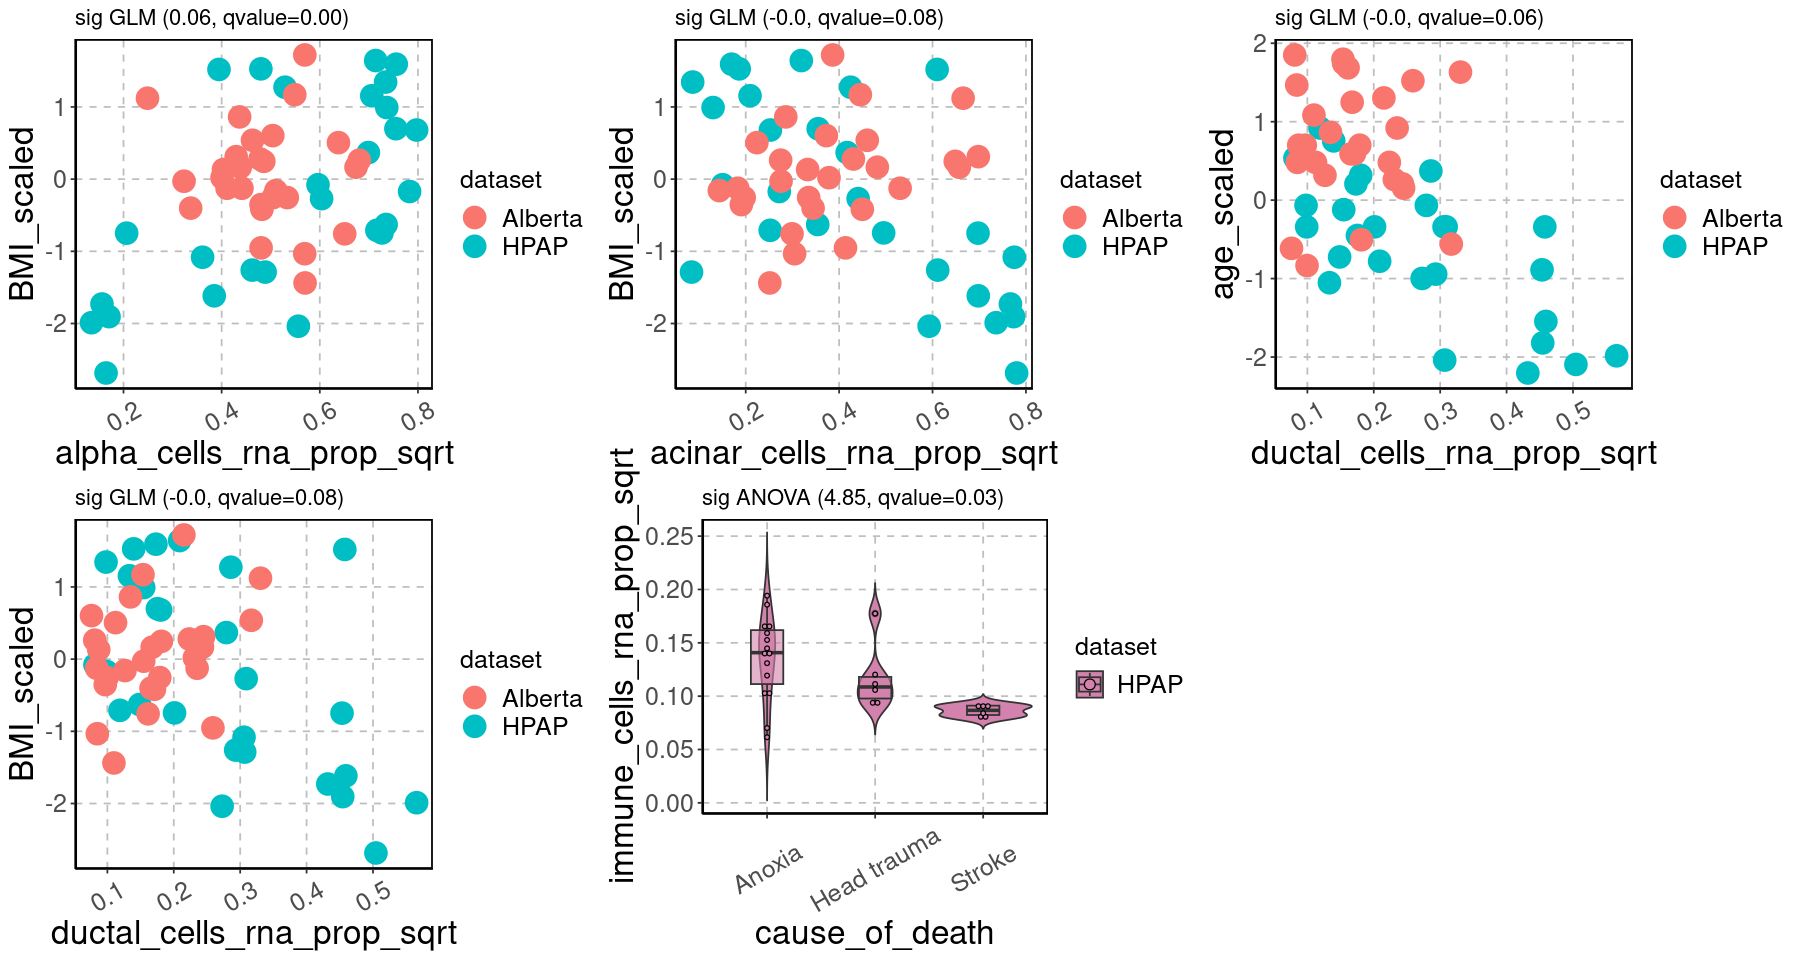

In [39]:
options(repr.plot.height=8, repr.plot.width=15)
fig1 <- suppressMessages(suppressWarnings(ggarrange(plotlist=plots, ncol=3, nrow=2)))
fig1

In [41]:
# options(repr.plot.height=12, repr.plot.width=15)
# fig1 <- suppressMessages(suppressWarnings(ggarrange(plotlist=plots[grepl('age|BMI|HbA1c',names(plots))], ncol=3, nrow=3)))
# fig1

# options(repr.plot.height=8, repr.plot.width=15)
# fig2 <- suppressMessages(suppressWarnings(ggarrange(plotlist=plots[grepl('purity',names(plots))], ncol=3, nrow=2)))
# fig2

## ATAC associations

In [42]:
plots <- wrapper_plot_sig_assocs(meta_fin, celltypes, 'ATAC', 0.1)
length(plots)

[1] 3

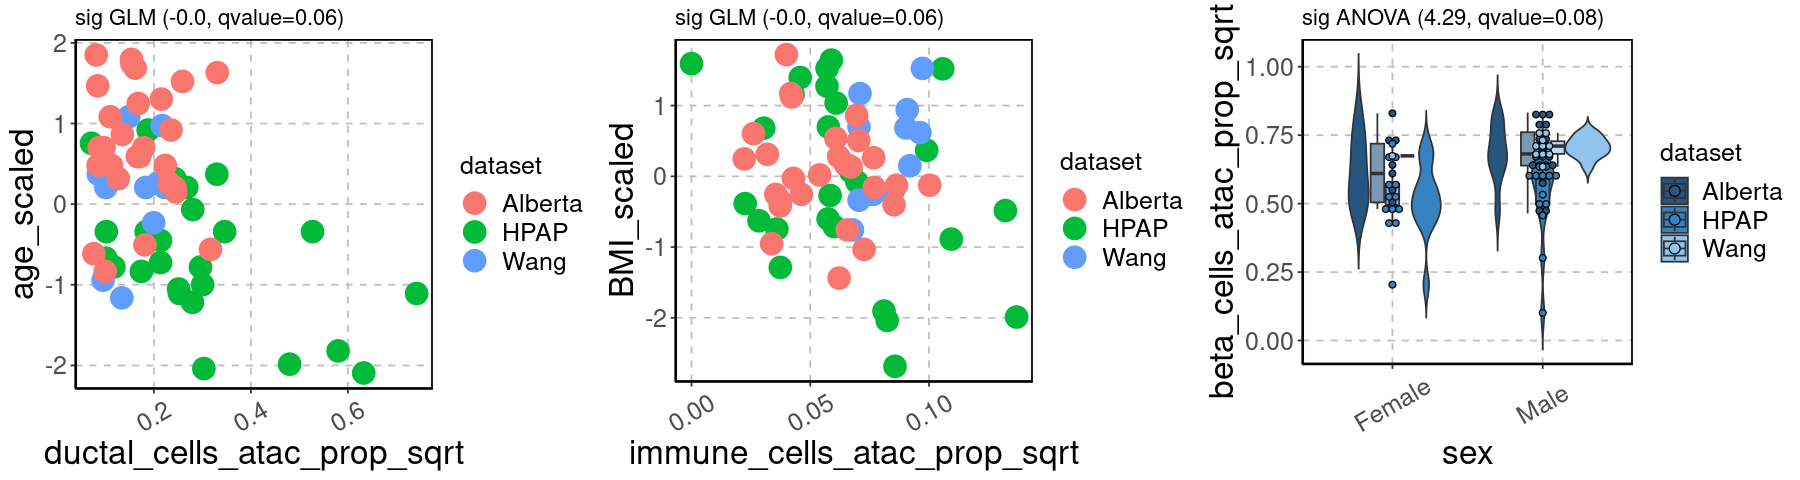

In [44]:
options(repr.plot.height=4, repr.plot.width=15)
fig1 <- suppressMessages(suppressWarnings(ggarrange(plotlist=plots, ncol=3, nrow=1)))
fig1

In [43]:
# options(repr.plot.height=8, repr.plot.width=15)
# fig1 <- suppressMessages(suppressWarnings(ggarrange(plotlist=plots[grepl('age|BMI|HbA1c',names(plots))], ncol=3, nrow=2)))
# fig1

# options(repr.plot.height=8, repr.plot.width=15)
# fig2 <- suppressMessages(suppressWarnings(ggarrange(plotlist=plots[grepl('purity',names(plots))], ncol=3, nrow=2)))
# fig2

# options(repr.plot.height=4, repr.plot.width=5)
# plots[6:8]

# Quick curiosity test -- cause of death differences?

### RNA

In [48]:
modality <- 'RNA'

#read in either 10k scaled counts or sqrt compartment proportion 
prop_fp <- file.path(indir, sprintf('all_datasets_donor_celltype_%s_props.tsv',modality))
df <- read.table(prop_fp, sep='\t', header=1)

# prep list of cell type prop values to test -- adjust based on input data
meta_use <- left_join(meta_fin, df, by='sample') %>%

plots <- list()
for(celltype in celltypes){
    data <- meta_use[,c('cause_of_death',sprintf('%s_cells_%s_prop',celltype,str_to_lower(modality)))]
    colnames(data)[2] <- 'ct_prop'
    
    options(repr.plot.height=5, repr.plot.width=5)
    p1 <- ggplot(data, aes(x=cause_of_death, y=ct_prop, fill=cause_of_death)) + 
                geom_violin(trim=FALSE) + 
                geom_boxplot(width=0.3, alpha=.6, fill='white') + 
                geom_dotplot(binaxis='y', stackdir='center', dotsize=1) + 
                labs(x = 'Cause of death', y = sprintf('%s cell %s prop',celltype,modality)) + 
                theme(axis.title=element_text(size=20),
                      axis.text.y=element_text(size=15),
                      axis.text.x=element_text(size=15, angle=30, vjust=0.5),
                      panel.grid.major=element_line(color='grey', size=0.5, linetype=2),
                      panel.grid.minor=element_blank(),
                      panel.border=element_rect(color='black',fill=NA, size=1),
                      legend.position='none')
    plots[[celltype]] <- p1
}

Warning message:
“Removed 18 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 18 rows containing non-finite values (`stat_boxplot()`).”
Bin width defaults to 1/30 of the range of the data. Pick better value with `binwidth`.
Warning message:
“Removed 46 rows containing missing values (`stat_bindot()`).”
Warning message:
“Removed 18 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 18 rows containing non-finite values (`stat_boxplot()`).”
Bin width defaults to 1/30 of the range of the data. Pick better value with `binwidth`.
Warning message:
“Removed 46 rows containing missing values (`stat_bindot()`).”
Warning message:
“Removed 18 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 18 rows containing non-finite values (`stat_boxplot()`).”
Bin width defaults to 1/30 of the range of the data. Pick better value with `binwidth`.
Warning message:
“Removed 46 rows containing missing values (`stat_bi

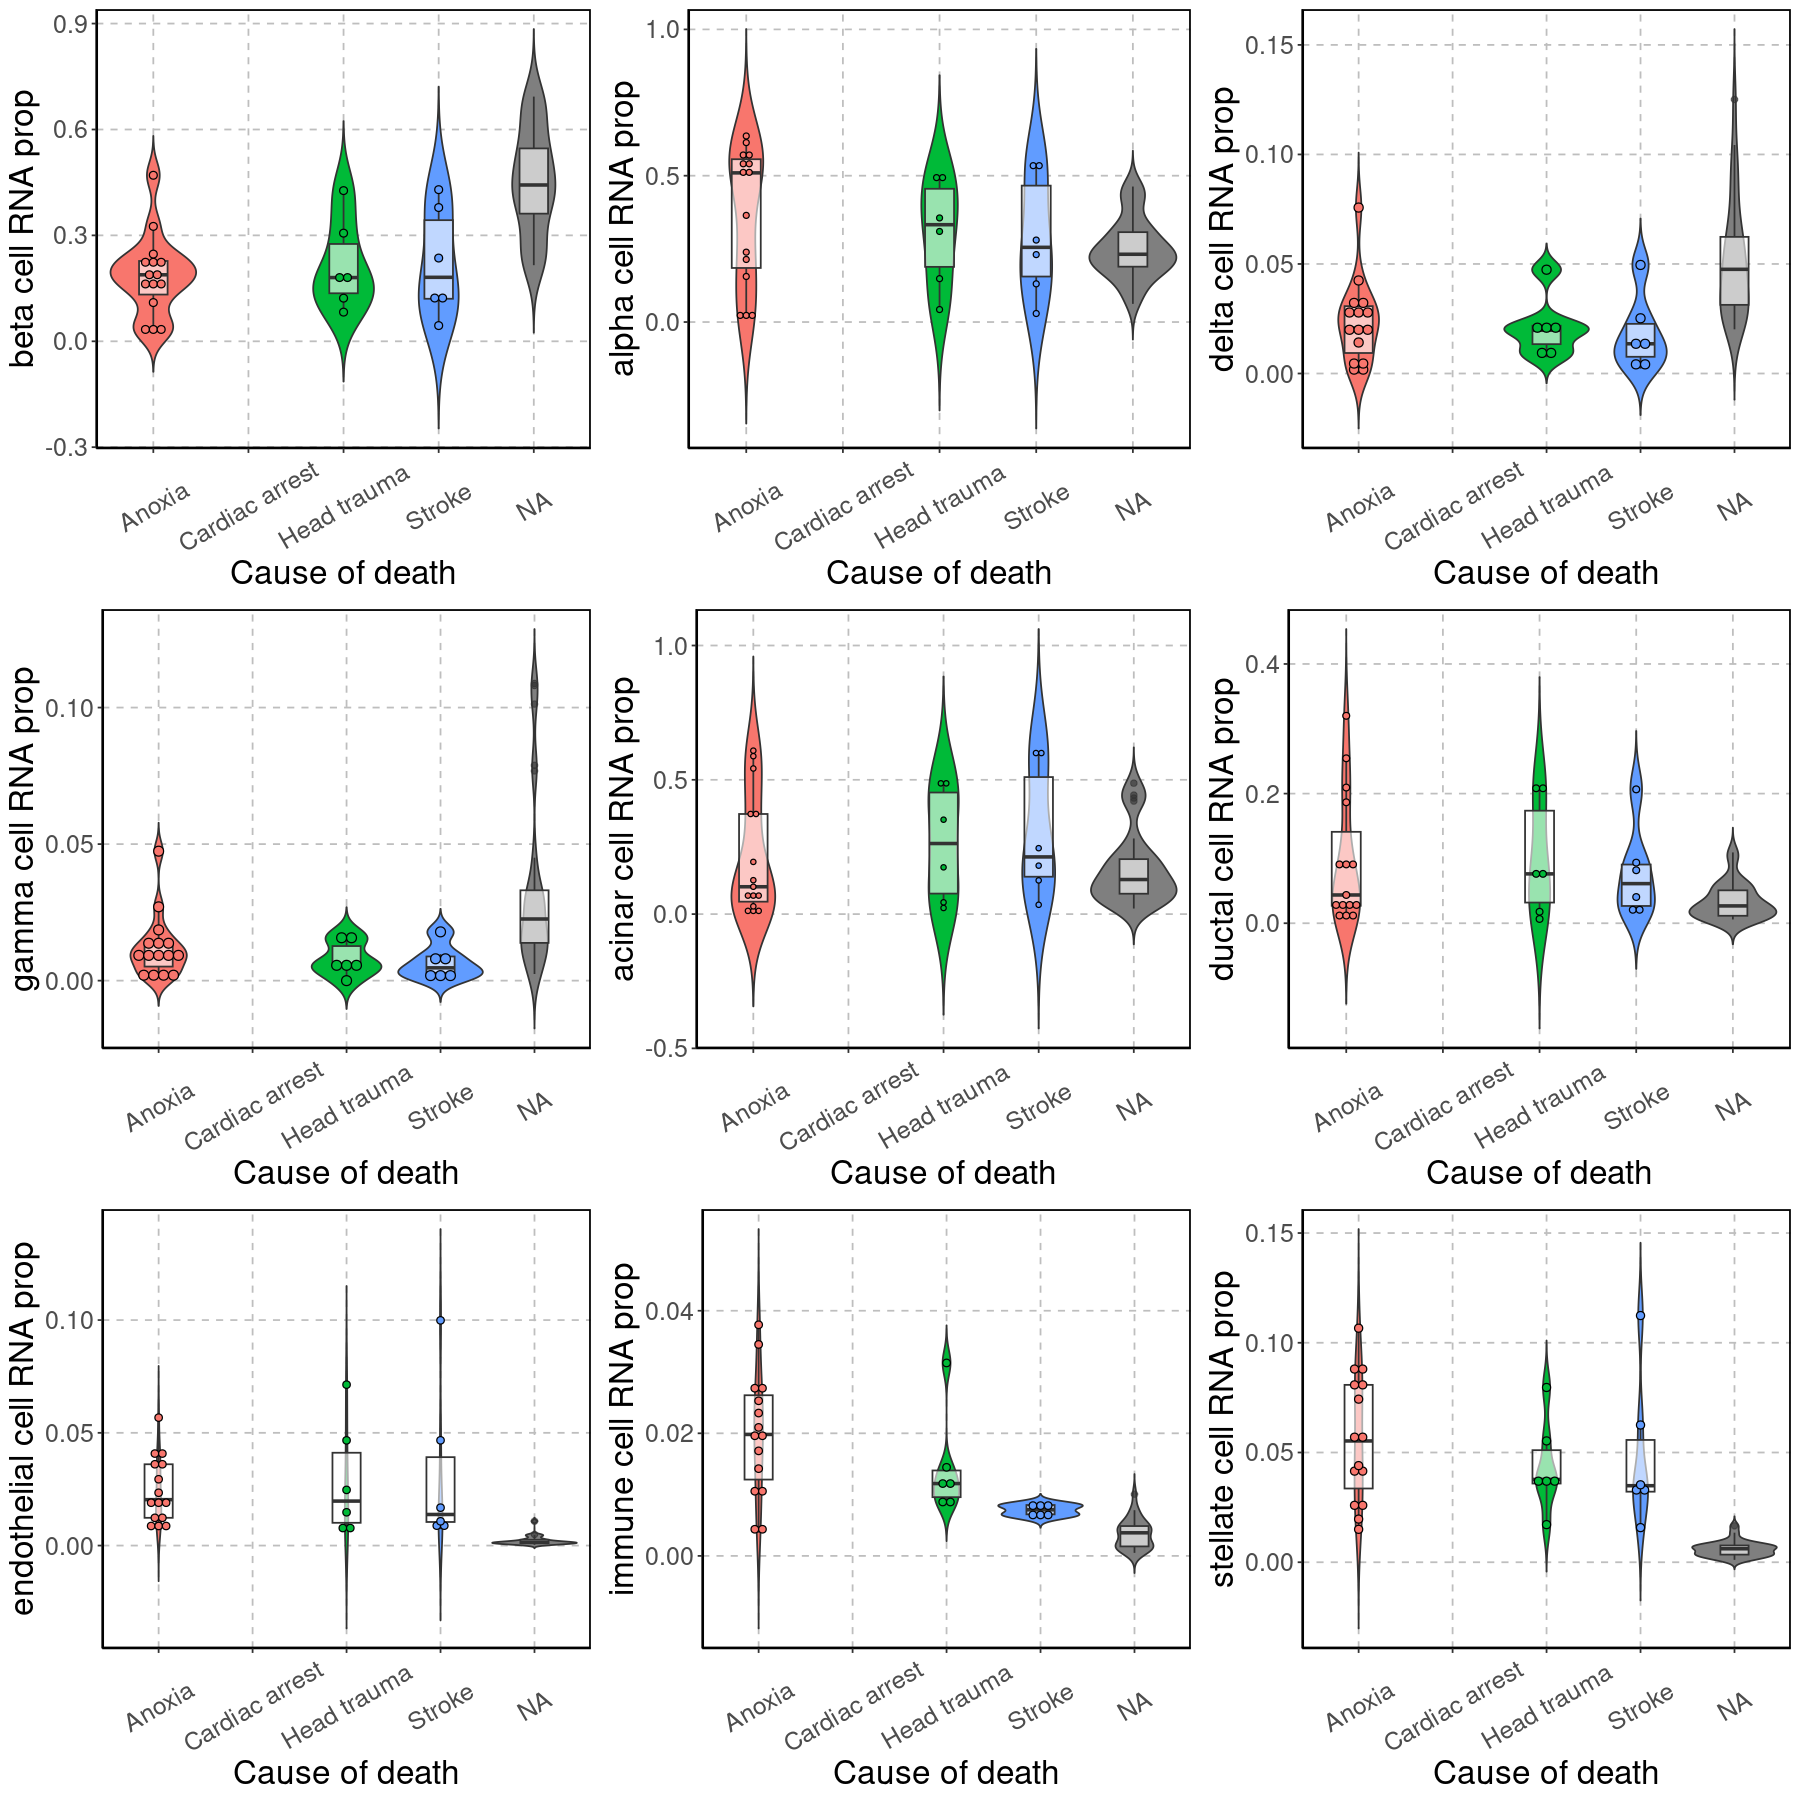

In [49]:
fig <- ggarrange(plotlist=plots, ncol=3, nrow=3)
options(repr.plot.width=15, repr.plot.height=15)
fig

In [47]:
res_df <- read.table('/nfs/lab/projects/multiomic_islet/outputs/revisions_outputs/trait_associations/celltype_props/outputs/RNA_disc.anova_onesided_wBH_FDR.txt',sep='\t', header=1)
subset(res_df, trait=='cause_of_death')

,trait,celltype,stat,pvalue,qvalue
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
10,cause_of_death,beta,0.20871911,0.81308085,0.81308085
11,cause_of_death,alpha,0.15786298,0.85484627,0.85484627
12,cause_of_death,delta,0.14852163,0.86276750,0.86276750
13,cause_of_death,gamma,0.90003498,0.41984047,0.82437387
14,cause_of_death,acinar,0.49179072,0.61755914,0.87576288
15,cause_of_death,ductal,0.04145936,0.95945688,0.95945688
16,cause_of_death,endothelial,0.03593118,0.96475848,0.96475848
17,cause_of_death,immune,4.85721724,0.01693341,0.03386681
18,cause_of_death,stellate,0.42056340,0.66142317,0.66142317


### ATAC

In [52]:
modality <- 'ATAC'

#read in either 10k scaled counts or sqrt compartment proportion 
prop_fp <- file.path(indir, sprintf('all_datasets_donor_celltype_%s_props.tsv',modality))
df <- read.table(prop_fp, sep='\t', header=1)

# prep list of cell type prop values to test -- adjust based on input data
meta_use <- left_join(meta_fin, df, by='sample')

plots <- list()
for(celltype in celltypes){
    data <- meta_use[,c('cause_of_death',sprintf('%s_cells_%s_prop',celltype,str_to_lower(modality)))]
    colnames(data)[2] <- 'ct_prop'
    
    options(repr.plot.height=5, repr.plot.width=5)
    p1 <- ggplot(data, aes(x=cause_of_death, y=ct_prop, fill=cause_of_death)) + 
                geom_violin(trim=FALSE) + 
                geom_boxplot(width=0.3, alpha=.6, fill='white') + 
                geom_dotplot(binaxis='y', stackdir='center', dotsize=1) + 
                labs(x = 'Cause of death', y = sprintf('%s cell %s prop',celltype,modality)) + 
                theme(axis.title=element_text(size=20),
                      axis.text.y=element_text(size=15),
                      axis.text.x=element_text(size=15, angle=30, vjust=0.5),
                      panel.grid.major=element_line(color='grey', size=0.5, linetype=2),
                      panel.grid.minor=element_blank(),
                      panel.border=element_rect(color='black',fill=NA, size=1),
                      legend.position='none')
    plots[[celltype]] <- p1
}

Warning message:
“Removed 7 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Removed 7 rows containing non-finite values (`stat_boxplot()`).”
Bin width defaults to 1/30 of the range of the data. Pick better value with `binwidth`.
Warning message:
“Removed 35 rows containing missing values (`stat_bindot()`).”
Warning message:
“Removed 7 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Removed 7 rows containing non-finite values (`stat_boxplot()`).”
Bin width defaults to 1/30 of the range of the data. Pick better value with `binwidth`.
Warning message:
“Removed 35 rows containing missing values (`stat_bindot()`).”
Warning message:
“Removed 7 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message

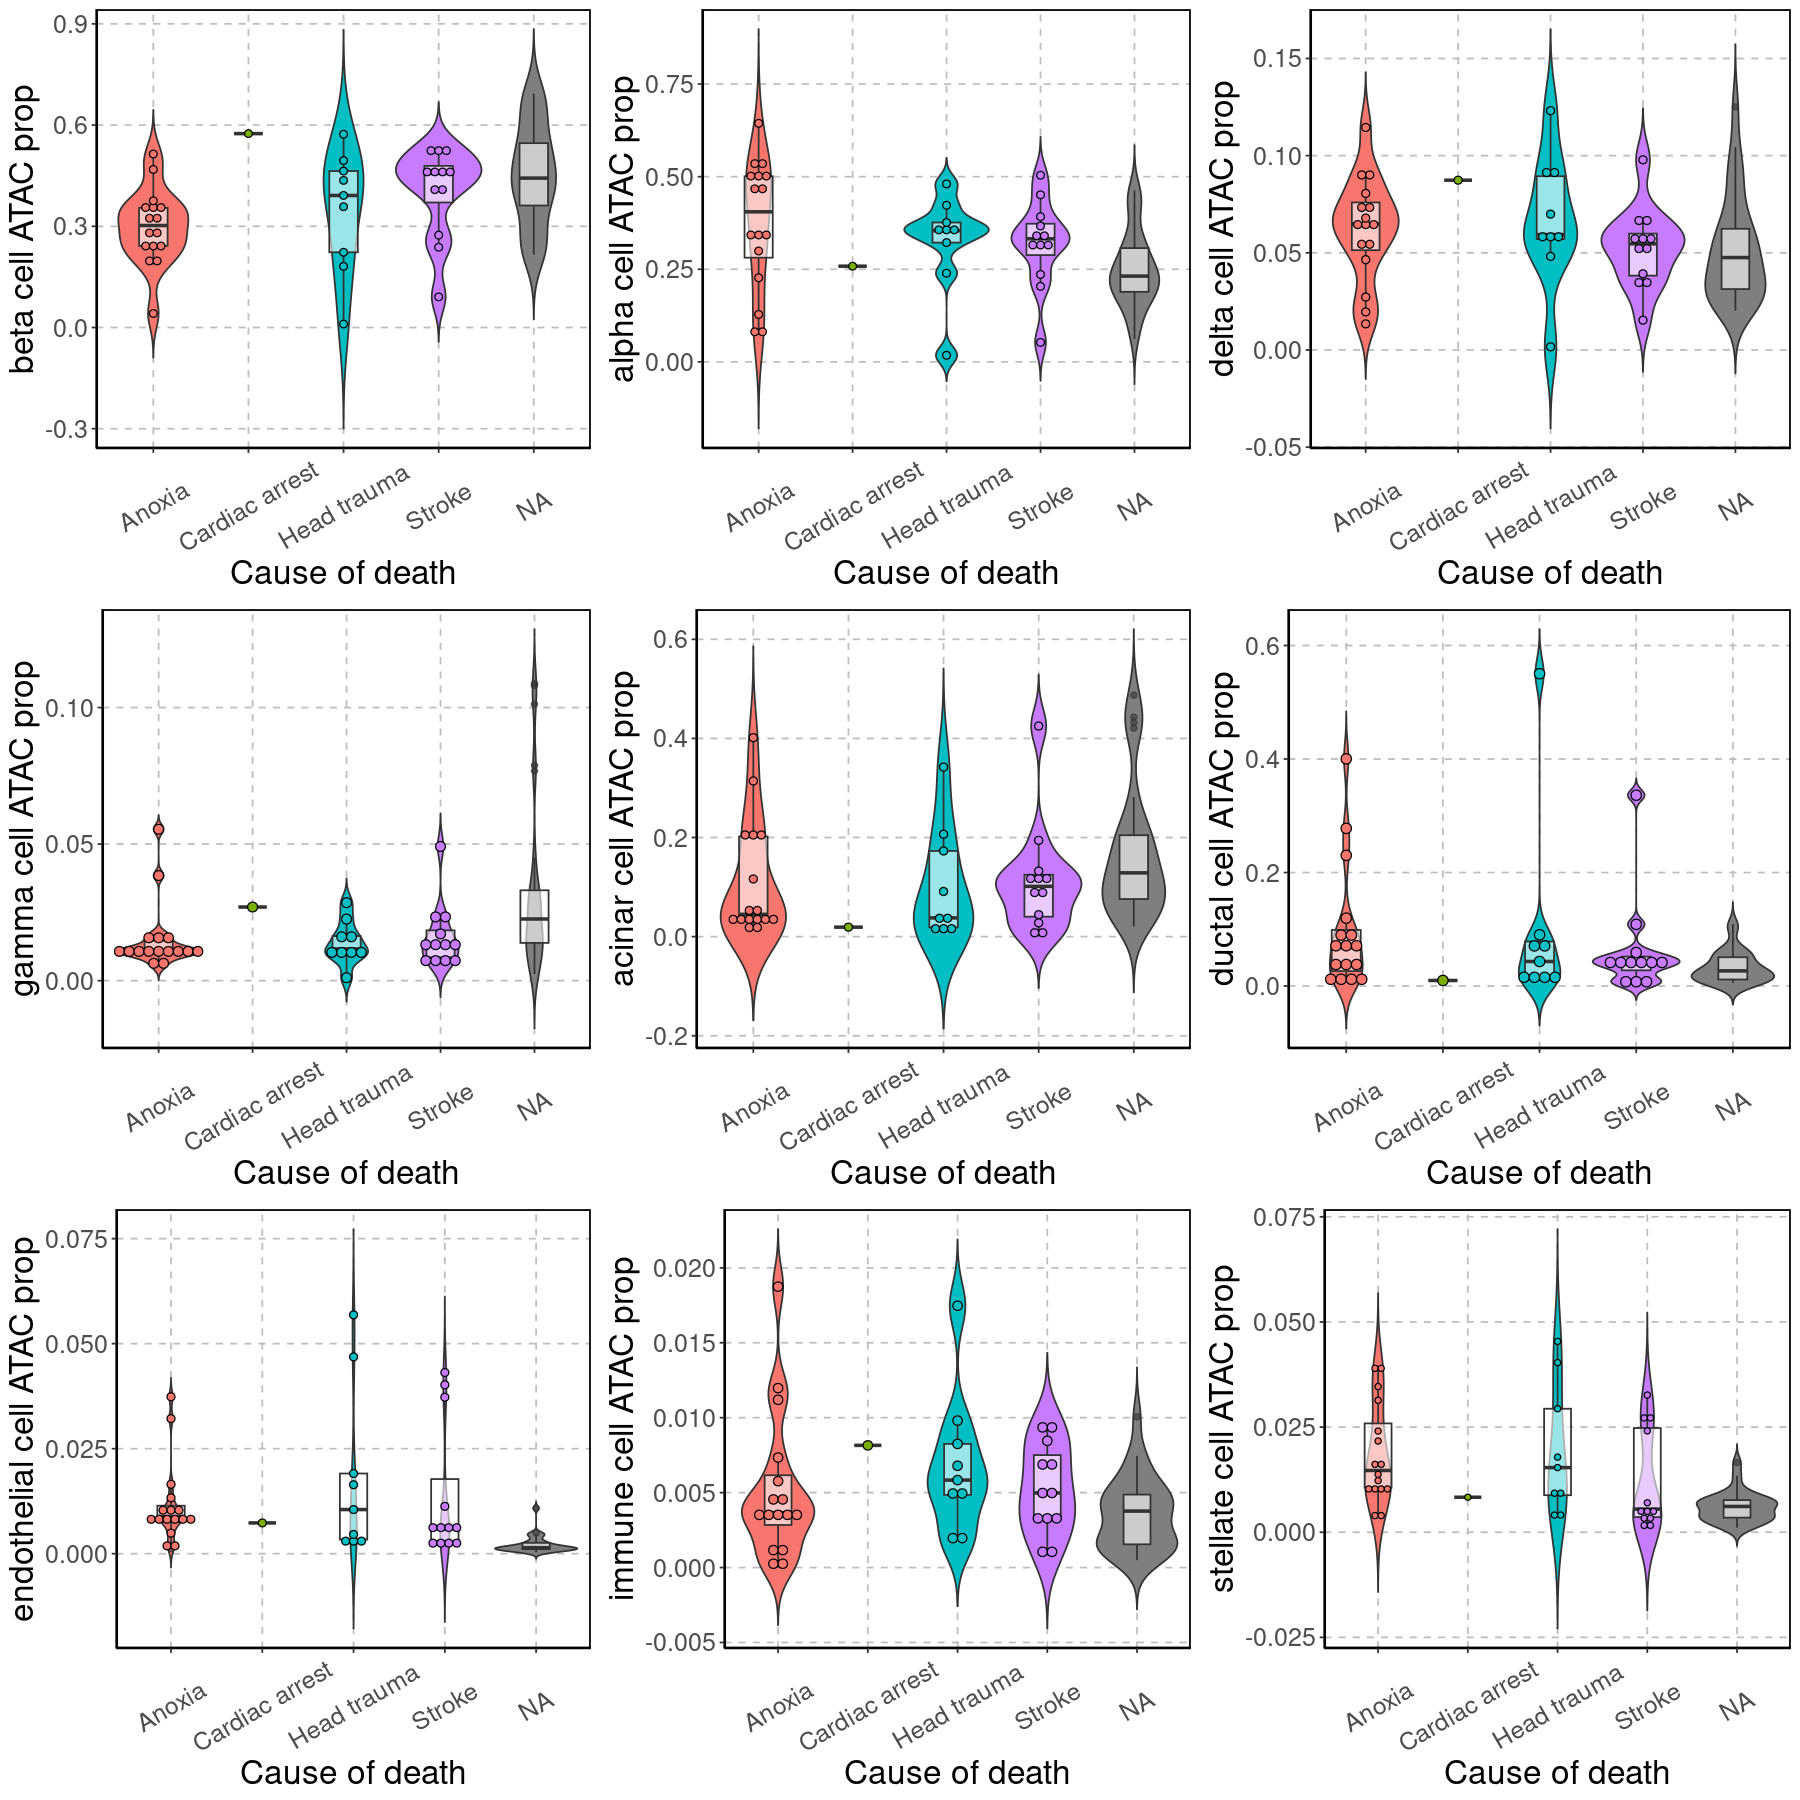

In [53]:
fig <- ggarrange(plotlist=plots, ncol=3, nrow=3)
options(repr.plot.width=15, repr.plot.height=15)
fig

In [54]:
res_df <- read.table('/nfs/lab/projects/multiomic_islet/outputs/revisions_outputs/trait_associations/celltype_props/outputs/ATAC_disc.anova_onesided_wBH_FDR.txt',sep='\t', header=1)
subset(res_df, trait=='cause_of_death')

,trait,celltype,stat,pvalue,qvalue
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
10,cause_of_death,beta,1.4129469,0.2558862,0.2558862
11,cause_of_death,alpha,0.2733653,0.8441714,0.8441714
12,cause_of_death,delta,0.5048098,0.6815509,0.6815509
13,cause_of_death,gamma,0.5308985,0.6641509,0.7457851
14,cause_of_death,acinar,0.3117347,0.8167456,0.8167456
15,cause_of_death,ductal,0.5559827,0.6476827,0.6476827
16,cause_of_death,endothelial,0.2214303,0.8808373,0.8808373
17,cause_of_death,immune,0.6179476,0.6081745,0.6081745
18,cause_of_death,stellate,1.2885471,0.2940549,0.2940549
